# InterMind, Dataset and Knowledge Base

## Run guide

**Purpose.** Convert O\*NET 31.0 into a compact interview knowledge base: one record per occupation holding its
O*NET-derived competency signal, technologies, and core tasks. This artifact grounds InterMind's question generation.

**Pipeline.** `Job Description > JobSpec > match to O*NET occupation > competencies + technologies + tasks > questions`

**How to run.**
1. `Runtime > Run all`, or run cells top to bottom.
2. No GPU required (pandas, scikit-learn, matplotlib only).
3. First run downloads O\*NET (~13 MB) to `data/raw/onet/` (resolved relative to the repo root; re-running
   reuses the cached extract and does not re-download). In a bare Colab runtime with no repo checked out,
   it falls back to `/content/data/raw/onet/`.
4. Processed artifacts are written to `data/processed/onet/` in Section 7 (same repo-root resolution).

**Runtime.** About 1 to 2 minutes (after the first download).

**Scope.** Only 4 of the 40+ O\*NET files are used. The others (interests, abilities, work context) are out of scope
for a first knowledge base.

**Outputs** (Section 7, in `data/processed/onet/`): `onet_kb.jsonl`, `occupation_index.csv`, `onet_kb_meta.json`, `README.md`.

**Validation.** Section 10 (end of notebook) is a single consolidated pass/fail report covering row counts,
duplicate and referential-integrity checks, schema checks, and missing-value handling.

## 1. Setup

In [1]:
import datetime
import io
import json
import os
import sys
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import requests

In [2]:
# Wider display for reading task and description text during exploration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

print("Environment ready.")

Environment ready.


In [3]:
# Resolve the repo root so this notebook behaves the same whether it's run from `notebooks/`
# inside a checkout (the normal case) or, as a fallback, in a bare Colab runtime with no repo.
# Raw downloads and processed artifacts are then kept under the repo's own data/ layout
# (data/raw/onet, data/processed/onet) instead of a notebooks/-relative or Colab-only path.


def _find_repo_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return None


IN_COLAB = "google.colab" in sys.modules
_repo_root = None if IN_COLAB else _find_repo_root(Path.cwd())

if _repo_root is not None:
    REPO_ROOT = _repo_root
elif IN_COLAB:
    REPO_ROOT = Path("/content")
else:
    # Last-resort fallback if pyproject.toml can't be found: assume cwd is notebooks/.
    REPO_ROOT = Path.cwd().parent

RAW_DIR = REPO_ROOT / "data" / "raw" / "onet"
PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "onet"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root     :", REPO_ROOT)
print("Raw data dir  :", RAW_DIR)
print("Processed dir :", PROCESSED_DIR)

Repo root     : C:\Users\Aliyah\Autonomous-AI-Interviewer
Raw data dir  : C:\Users\Aliyah\Autonomous-AI-Interviewer\data\raw\onet
Processed dir : C:\Users\Aliyah\Autonomous-AI-Interviewer\data\processed\onet


## 2. Download O\*NET

In [4]:
# Official tab-delimited release, cached under data/raw/onet/ so re-running the notebook does
# not re-download ~13 MB each time. Delete that folder to force a fresh download.
ONET_BASE_URL = "https://www.onetcenter.org/dl_files/database/db_31_0_text.zip"
ONET_DIR = RAW_DIR / "db_31_0_text"

if ONET_DIR.exists() and any(ONET_DIR.iterdir()):
    print(f"O*NET 31.0 already extracted at {ONET_DIR}, skipping download.")
else:
    response = requests.get(ONET_BASE_URL, timeout=60)
    response.raise_for_status()
    print(f"Downloaded: {len(response.content) / (1024 * 1024):.2f} MB")

    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        z.extractall(RAW_DIR)

    print(f"O*NET 31.0 extracted to {ONET_DIR}")

O*NET 31.0 already extracted at C:\Users\Aliyah\Autonomous-AI-Interviewer\data\raw\onet\db_31_0_text, skipping download.


In [5]:
# Confirm the full release extracted. Only 4 of the 45+ files here are used (see the Run
# guide's Scope note) -- list the count and a sample rather than all file names.
all_files = sorted(p.name for p in ONET_DIR.glob("*.txt"))
print(f"{len(all_files)} .txt files extracted to {ONET_DIR}")
print("Sample:", all_files[:8])

46 .txt files extracted to C:\Users\Aliyah\Autonomous-AI-Interviewer\data\raw\onet\db_31_0_text
Sample: ['Abilities to Work Activities.txt', 'Abilities to Work Context.txt', 'Abilities.txt', 'Career Interest Type Keywords.txt', 'Career Interest Types.txt', 'Content Model Reference.txt', 'Education Categories.txt', 'Education.txt']


In [6]:
# Only these four files are needed. All join on O*NET-SOC Code.
REQUIRED_FILES = {
    "occupation": "Occupation Data.txt",  # hub: code, title, description
    "software_skills": "Software Skills.txt",  # technologies used on the job
    "essential_skills": "Essential Skills.txt",  # O*NET Skills, rated by importance/level
    "tasks": "Task Statements.txt",  # occupational tasks
}

_missing_files = []
for name, filename in REQUIRED_FILES.items():
    path = ONET_DIR / filename
    exists = path.exists()
    print(f"{name:<18} {filename:<24} {exists}")
    if not exists:
        _missing_files.append(filename)

if _missing_files:
    raise FileNotFoundError(f"Missing required O*NET source file(s): {_missing_files}")

print("\nAll required source files present. Dataset directory:", ONET_DIR)

occupation         Occupation Data.txt      True
software_skills    Software Skills.txt      True
essential_skills   Essential Skills.txt     True
tasks              Task Statements.txt      True

All required source files present. Dataset directory: C:\Users\Aliyah\Autonomous-AI-Interviewer\data\raw\onet\db_31_0_text


In [7]:
# All O*NET text files are tab-separated. Load with a small guard so a malformed or
# unexpectedly-shaped file fails loudly here rather than downstream.
def load_onet_table(path: Path, required_columns: list[str]) -> pd.DataFrame:
    try:
        df = pd.read_csv(path, sep="\t", encoding="utf-8")
    except UnicodeDecodeError:
        df = pd.read_csv(path, sep="\t", encoding="latin-1")

    if df.empty:
        raise ValueError(f"{path.name}: loaded an empty table")

    missing_cols = set(required_columns) - set(df.columns)
    if missing_cols:
        raise ValueError(f"{path.name}: missing expected column(s) {sorted(missing_cols)}")

    return df


occupation_df = load_onet_table(
    ONET_DIR / REQUIRED_FILES["occupation"], ["O*NET-SOC Code", "Title", "Description"]
)
software_skills_df = load_onet_table(
    ONET_DIR / REQUIRED_FILES["software_skills"],
    ["O*NET-SOC Code", "Workplace Example", "Element Name", "Hot Technology", "In Demand"],
)
essential_skills_df = load_onet_table(
    ONET_DIR / REQUIRED_FILES["essential_skills"],
    ["O*NET-SOC Code", "Element Name", "Scale ID", "Data Value", "Recommend Suppress", "Not Relevant"],
)
tasks_df = load_onet_table(
    ONET_DIR / REQUIRED_FILES["tasks"],
    ["O*NET-SOC Code", "Task ID", "Task", "Task Type", "Incumbents Responding"],
)

print("Occupation:", occupation_df.shape)
print("Software Skills:", software_skills_df.shape)
print("Essential Skills:", essential_skills_df.shape)
print("Tasks:", tasks_df.shape)

Occupation: (1016, 3)
Software Skills: (31821, 6)
Essential Skills: (18200, 13)
Tasks: (18838, 7)


### First look at each table

In [8]:
display(occupation_df.head())

,O*NET-SOC Code,Title,Description
0,11-1011.00,Chief Executives,Determine and formulate policies and provide overall direction of companies or private and public sector organizations within guidelines set up by...
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, shareholders, customers, and employees to address sustainability issues. Enact or oversee a corporate ..."
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of public or private sector organizations, overseeing multiple departments or locations. Duties and res..."
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes at the local, tribal, state, or federal level. Includes only workers in elected positions."
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising policies and programs or produce collateral materials, such as posters, contests, coupons, or giveaways, t..."


In [9]:
display(software_skills_df.head())

,O*NET-SOC Code,Workplace Example,Element ID,Element Name,Hot Technology,In Demand
0,11-1011.00,Adobe Acrobat,2.E.5.b,Document management software,Y,N
1,11-1011.00,AdSense Tracker,2.E.6.f,Data base user interface and query software,N,N
2,11-1011.00,Atlassian JIRA,2.E.5.a,Content workflow software,Y,N
3,11-1011.00,Blackbaud The Raiser's Edge,2.E.6.c,Customer relationship management CRM software,N,N
4,11-1011.00,ComputerEase construction accounting software,2.E.2.a,Accounting software,N,N


In [10]:
display(essential_skills_df.head())

,O*NET-SOC Code,Element ID,Element Name,Scale ID,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source
0,11-1011.00,2.A.1.a,Reading Comprehension,IM,4.12,8,0.1250,3.8800,4.3700,N,NaN,08/2023,Analyst
1,11-1011.00,2.A.1.a,Reading Comprehension,LV,4.62,8,0.1830,4.2664,4.9836,N,N,08/2023,Analyst
2,11-1011.00,2.A.1.b,Active Listening,IM,4.00,8,0.0000,4.0000,4.0000,N,NaN,08/2023,Analyst
3,11-1011.00,2.A.1.b,Active Listening,LV,4.75,8,0.1637,4.4292,5.0708,N,N,08/2023,Analyst
4,11-1011.00,2.A.1.c,Writing,IM,4.12,8,0.1250,3.8800,4.3700,N,NaN,08/2023,Analyst


In [11]:
display(tasks_df.head())

,O*NET-SOC Code,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source
0,11-1011.00,8823,"Direct or coordinate an organization's financial or budget activities to fund operations, maximize investments, or increase efficiency.",Core,95.0,08/2023,Incumbent
1,11-1011.00,8824,"Confer with board members, organization officials, or staff members to discuss issues, coordinate activities, or resolve problems.",Core,95.0,08/2023,Incumbent
2,11-1011.00,8827,"Prepare budgets for approval, including those for funding or implementation of programs.",Core,95.0,08/2023,Incumbent
3,11-1011.00,8826,"Direct, plan, or implement policies, objectives, or activities of organizations or businesses to ensure continuing operations, to maximize returns...",Core,94.0,08/2023,Incumbent
4,11-1011.00,8834,"Prepare or present reports concerning activities, expenses, budgets, government statutes or rulings, or other items affecting businesses or progra...",Core,95.0,08/2023,Incumbent


### Column inspection

In [12]:
# Confirm which field holds what before transforming.
for name, df in {
    "Occupation": occupation_df,
    "Software Skills": software_skills_df,
    "Essential Skills": essential_skills_df,
    "Tasks": tasks_df,
}.items():
    print(f"\n{'='*60}")
    print(name)
    print("="*60)
    print(df.columns.tolist())


Occupation
['O*NET-SOC Code', 'Title', 'Description']

Software Skills
['O*NET-SOC Code', 'Workplace Example', 'Element ID', 'Element Name', 'Hot Technology', 'In Demand']

Essential Skills
['O*NET-SOC Code', 'Element ID', 'Element Name', 'Scale ID', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Not Relevant', 'Date', 'Domain Source']

Tasks
['O*NET-SOC Code', 'Task ID', 'Task', 'Task Type', 'Incumbents Responding', 'Date', 'Domain Source']


### Missing values

In [13]:
# Expect the fields used downstream (titles, descriptions, tasks, skill/tech names) to be complete.
for name, df in {
    "Occupation": occupation_df,
    "Software Skills": software_skills_df,
    "Essential Skills": essential_skills_df,
    "Tasks": tasks_df,
}.items():
    print(f"\n{name}")
    print(df.isna().sum())


Occupation
O*NET-SOC Code    0
Title             0
Description       0
dtype: int64

Software Skills
O*NET-SOC Code       0
Workplace Example    0
Element ID           0
Element Name         0
Hot Technology       0
In Demand            0
dtype: int64

Essential Skills
O*NET-SOC Code           0
Element ID               0
Element Name             0
Scale ID                 0
Data Value               0
N                        0
Standard Error           0
Lower CI Bound           0
Upper CI Bound           0
Recommend Suppress       0
Not Relevant          9100
Date                     0
Domain Source            0
dtype: int64

Tasks
O*NET-SOC Code             0
Task ID                    0
Task                       0
Task Type                418
Incumbents Responding    587
Date                       0
Domain Source              0
dtype: int64


Fields used directly by the knowledge base (titles, descriptions, technology names, skill names and
rating values, task text) are complete. The remaining nulls are survey metadata with documented meaning,
not defects -- rows are **not** dropped just because these columns are blank:

- **Essential Skills `Not Relevant` (9,100 blank):** O*NET marks this `Y` when a skill was explicitly
  rated not relevant to an occupation. A blank means O*NET did *not* flag it either way -- the row is
  kept. Only rows explicitly flagged `Y` are excluded when building competency signals (Section 5.3).
- **Tasks `Task Type` (418 blank) / `Incumbents Responding` (587 blank):** `Task Type` is `Core` or
  `Supplemental`; a blank is treated as "not Core" (Section 5.4's selection logic falls back to it only
  when an occupation has zero Core tasks). `Incumbents Responding` is survey metadata (how many
  respondents rated the task) and is not used by the pipeline at all -- it is not loaded into the
  knowledge base.

A dedicated data-quality section below checks these (and other) fields for duplicates, invalid
references, and out-of-range values before any transformation happens.

### Data quality checks

Before any transformation: duplicate keys, missing/blank join codes, unexpected blank text fields, and
numeric fields outside their documented O*NET scale ranges. These checks **report** problems; they do not
silently drop rows.

In [14]:
def count_duplicates(df, key_cols):
    return int(df.duplicated(subset=key_cols).sum())


def count_missing_codes(df, code_col="O*NET-SOC Code"):
    return int(df[code_col].isna().sum() + df[code_col].astype(str).str.strip().eq("").sum())


def count_blank(df, col):
    return int(df[col].astype(str).str.strip().eq("").sum())


print("=== Duplicate keys ===")
dup_occ = count_duplicates(occupation_df, ["O*NET-SOC Code"])
dup_soft = count_duplicates(software_skills_df, ["O*NET-SOC Code", "Element ID", "Workplace Example"])
dup_ess = count_duplicates(essential_skills_df, ["O*NET-SOC Code", "Element ID", "Scale ID"])
dup_tasks = count_duplicates(tasks_df, ["O*NET-SOC Code", "Task ID"])
print(f"Occupation (O*NET-SOC Code)                         : {dup_occ}  (must be 0, it's the hub key)")
print(f"Software Skills (code, Element ID, Workplace Example): {dup_soft}")
print(f"Essential Skills (code, Element ID, Scale ID)        : {dup_ess}")
print(f"Tasks (code, Task ID)                                 : {dup_tasks}")
assert dup_occ == 0, "Occupation Data must have exactly one row per O*NET-SOC Code"

print("\n=== Missing / blank O*NET-SOC Code ===")
for name, df in {
    "Occupation": occupation_df,
    "Software Skills": software_skills_df,
    "Essential Skills": essential_skills_df,
    "Tasks": tasks_df,
}.items():
    print(f"{name:<18}: {count_missing_codes(df)}")

print("\n=== Unexpected blank strings in key text fields ===")
print(f"Occupation.Title           : {count_blank(occupation_df, 'Title')}")
print(f"Occupation.Description     : {count_blank(occupation_df, 'Description')}")
print(f"Software Skills.Workplace Example : {count_blank(software_skills_df, 'Workplace Example')}")
print(f"Essential Skills.Element Name     : {count_blank(essential_skills_df, 'Element Name')}")
print(f"Tasks.Task                        : {count_blank(tasks_df, 'Task')}")

print("\n=== Per-occupation record counts (raw, before caps) ===")
for name, df in {
    "Software Skills": software_skills_df,
    "Essential Skills": essential_skills_df,
    "Tasks": tasks_df,
}.items():
    counts = df.groupby("O*NET-SOC Code").size()
    print(f"{name:<18}: min={counts.min()}, median={counts.median():.0f}, max={counts.max()}")

=== Duplicate keys ===
Occupation (O*NET-SOC Code)                         : 0  (must be 0, it's the hub key)
Software Skills (code, Element ID, Workplace Example): 0
Essential Skills (code, Element ID, Scale ID)        : 0
Tasks (code, Task ID)                                 : 0

=== Missing / blank O*NET-SOC Code ===
Occupation        : 0


Software Skills   : 0
Essential Skills  : 0
Tasks             : 0

=== Unexpected blank strings in key text fields ===
Occupation.Title           : 0
Occupation.Description     : 0
Software Skills.Workplace Example : 0
Essential Skills.Element Name     : 0
Tasks.Task                        : 0

=== Per-occupation record counts (raw, before caps) ===
Software Skills   : min=1, median=21, max=430
Essential Skills  : min=20, median=20, max=20
Tasks             : min=4, median=20, max=40


In [15]:
# Numeric range checks against O*NET's documented scales (Scales Reference.txt): Importance (IM)
# is rated 1-5, Level (LV) is rated 0-7. Out-of-range values would indicate a parsing or source
# problem -- report them rather than silently clipping or dropping.
print("=== Essential Skills: Data Value range by scale ===")
for scale, lo, hi in [("IM", 1, 5), ("LV", 0, 7)]:
    vals = pd.to_numeric(
        essential_skills_df.loc[essential_skills_df["Scale ID"] == scale, "Data Value"],
        errors="coerce",
    ).dropna()
    out_of_range = int(((vals < lo) | (vals > hi)).sum())
    print(f"{scale}: n={len(vals)}, range=[{vals.min():.2f}, {vals.max():.2f}], "
          f"expected=[{lo}, {hi}], out_of_range={out_of_range}")

print("\n=== Tasks: Incumbents Responding ===")
inc = pd.to_numeric(tasks_df["Incumbents Responding"], errors="coerce").dropna()
print(f"n={len(inc)} (non-null), range=[{inc.min():.0f}, {inc.max():.0f}], "
      f"non-positive={int((inc <= 0).sum())}")
print("Not used by the pipeline -- reported here for data-quality awareness only.")

=== Essential Skills: Data Value range by scale ===
IM: n=9100, range=[1.00, 5.00], expected=[1, 5], out_of_range=0
LV: n=9100, range=[0.00, 6.00], expected=[0, 7], out_of_range=0

=== Tasks: Incumbents Responding ===
n=18251 (non-null), range=[15, 233], non-positive=0
Not used by the pipeline -- reported here for data-quality awareness only.


### Available occupations

In [16]:
occupation_df[["O*NET-SOC Code", "Title"]].head(20)

,O*NET-SOC Code,Title
0,11-1011.00,Chief Executives
1,11-1011.03,Chief Sustainability Officers
2,11-1021.00,General and Operations Managers
3,11-1031.00,Legislators
4,11-2011.00,Advertising and Promotions Managers
5,11-2021.00,Marketing Managers
6,11-2022.00,Sales Managers
7,11-2032.00,Public Relations Managers
8,11-2033.00,Fundraising Managers
9,11-3012.00,Administrative Services Managers


In [17]:
# Random sample to gauge breadth across sectors.
occupation_df["Title"].sample(20, random_state=42).tolist()

['Hazardous Materials Removal Workers',
 'Medical Equipment Preparers',
 'Microbiologists',
 'First-Line Supervisors of Material-Moving Machine and Vehicle Operators',
 'Inspectors, Testers, Sorters, Samplers, and Weighers',
 'Forest Fire Inspectors and Prevention Specialists',
 'Camera and Photographic Equipment Repairers',
 'Mechanical Engineering Technologists and Technicians',
 'Geneticists',
 'Gambling and Sports Book Writers and Runners',
 'Locker Room, Coatroom, and Dressing Room Attendants',
 'Speech-Language Pathologists',
 'Gambling Surveillance Officers and Gambling Investigators',
 'Crematory Operators',
 'Solar Photovoltaic Installers',
 'Sound Engineering Technicians',
 'Extruding and Forming Machine Setters, Operators, and Tenders, Synthetic and Glass Fibers',
 'Curators',
 'Pesticide Handlers, Sprayers, and Applicators, Vegetation',
 'Installation, Maintenance, and Repair Workers, All Other']

## 3. Configuration

These caps limit how much is kept per occupation, keeping the knowledge base small and interview-focused.

In [18]:
# Signal caps per occupation (InterMind-defined limits, not O*NET values). These keep the
# knowledge base small and interview-focused; see Sections 5.2-5.4 for the selection logic
# each cap applies to.
TOP_N_TECHNOLOGIES = 25
TOP_N_COMPETENCIES = 12
TOP_N_CORE_TASKS = 15

# Output location: data/processed/onet/ in the repo (PROCESSED_DIR, resolved in Section 1).
OUT_DIR = PROCESSED_DIR

ONET_VERSION = "31.0"
print("Config ready:", OUT_DIR)

Config ready: C:\Users\Aliyah\Autonomous-AI-Interviewer\data\processed\onet


## 4. How the four files relate

All tables join on `O*NET-SOC Code` (e.g. `15-1252.00` = Software Developers).

| Table | Role | Grain |
|---|---|---|
| `Occupation Data` | hub / catalogue | 1 row per occupation |
| `Software Skills` | technologies (name in `Workplace Example`) | many rows per occupation |
| `Essential Skills` | competencies with importance (`Scale ID` = `IM`) | many rows per occupation |
| `Task Statements` | tasks (`Task Type` = `Core` / `Supplemental`) | many rows per occupation |

One hub and three one-to-many detail tables. The check below confirms the key and measures coverage, since not every
occupation appears in every detail table.

In [19]:
# Confirm the join key and measure coverage, at both the occupation level and the row level.
occ_codes = set(occupation_df["O*NET-SOC Code"])
soft_codes = set(software_skills_df["O*NET-SOC Code"])
ess_codes = set(essential_skills_df["O*NET-SOC Code"])
task_codes = set(tasks_df["O*NET-SOC Code"])

print(f"Occupation codes (hub): {len(occ_codes)}")

detail_tables = {
    "Software Skills": software_skills_df,
    "Essential Skills": essential_skills_df,
    "Tasks": tasks_df,
}

referential_orphans = {}
for name, df in detail_tables.items():
    codes = set(df["O*NET-SOC Code"])
    matched_rows = int(df["O*NET-SOC Code"].isin(occ_codes).sum())
    unmatched_rows = len(df) - matched_rows
    orphan_codes = codes - occ_codes
    referential_orphans[name] = orphan_codes

    print(f"\n{name}:")
    print(f"  occupations covered     : {len(codes & occ_codes)} / {len(occ_codes)}")
    print(f"  rows matched to hub     : {matched_rows}")
    print(f"  rows NOT matched to hub : {unmatched_rows}")
    print(f"  orphan codes            : {len(orphan_codes)}")
    if orphan_codes:
        print(f"  orphan code sample      : {sorted(orphan_codes)[:5]}")

Occupation codes (hub): 1016



Software Skills:
  occupations covered     : 923 / 1016
  rows matched to hub     : 31821
  rows NOT matched to hub : 0
  orphan codes            : 0

Essential Skills:
  occupations covered     : 910 / 1016
  rows matched to hub     : 18200
  rows NOT matched to hub : 0
  orphan codes            : 0

Tasks:
  occupations covered     : 923 / 1016
  rows matched to hub     : 18838
  rows NOT matched to hub : 0
  orphan codes            : 0


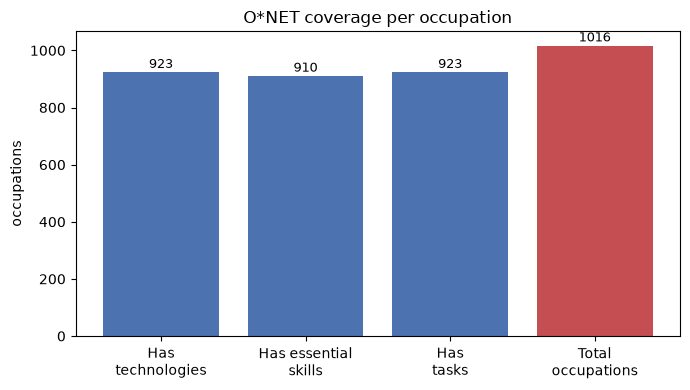

In [20]:
# Coverage: occupations carrying each kind of signal
import matplotlib.pyplot as plt

labels = ["Has\ntechnologies", "Has essential\nskills", "Has\ntasks", "Total\noccupations"]
values = [len(occ_codes & soft_codes), len(occ_codes & ess_codes),
          len(occ_codes & task_codes), len(occ_codes)]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=["#4C72B0","#4C72B0","#4C72B0","#C44E52"])
ax.set_title("O*NET coverage per occupation")
ax.set_ylabel("occupations")
for b, v in zip(bars, values):
    ax.text(b.get_x()+b.get_width()/2, v+5, str(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

Coverage gaps are expected. Some roles (e.g. Chief Executives) carry little or no technology data. The occupation
is retained with empty lists rather than dropped, and question generation adapts to whatever signal is present.

## 5. Reduce each detail table to interview signal

Each transform strips a detail table to the fields that inform a question and caps volume per occupation. The functions
are pure, which keeps the build deterministic and repeatable.

In [21]:
def _yn(series):
    """O*NET flag columns are 'Y' or blank. Return a boolean."""
    return series.astype(str).str.strip().str.upper().eq("Y")

### 5.1 Occupation base

Role identity only: code, title, description. The description is the main free-text signal and feeds the matchable
text later.

In [22]:
def build_occupation_base(df):
    base = (df.rename(columns={"O*NET-SOC Code":"onet_soc_code",
                               "Title":"title", "Description":"description"})
              [["onet_soc_code","title","description"]]
              .assign(title=lambda d: d.title.str.strip(),
                      description=lambda d: d.description.str.strip()))
    before = len(base)
    base = base.drop_duplicates("onet_soc_code").reset_index(drop=True)
    dropped = before - len(base)
    if dropped:
        print(f"build_occupation_base: dropped {dropped} duplicate onet_soc_code row(s)")
    return base

occ_base = build_occupation_base(occupation_df)
print(occ_base.shape)
occ_base.head(3)

(1016, 3)


,onet_soc_code,title,description
0,11-1011.00,Chief Executives,Determine and formulate policies and provide overall direction of companies or private and public sector organizations within guidelines set up by...
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, shareholders, customers, and employees to address sustainability issues. Enact or oversee a corporate ..."
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of public or private sector organizations, overseeing multiple departments or locations. Duties and res..."


### 5.2 Technologies

Column meaning:
- `Workplace Example`: the concrete technology (Python, Tableau, Docker). This is the interview target.
- `Element Name`: the broad UNSPSC category. Context only.
- `Hot Technology`, `In Demand`: O\*NET-provided flags for trending or employer-requested tech.

**InterMind heuristic, not an O\*NET ranking:** O*NET does not rank technologies within an occupation. The
priority order below (`hot` technologies first, then `in_demand`, ties broken alphabetically by name) is
an InterMind-defined heuristic used only to decide which technologies survive the `TOP_N_TECHNOLOGIES`
cap. It is deterministic (a stable sort on fixed keys) and documented here so it can be revisited without
being mistaken for an O*NET-provided importance measure.

Duplicates are collapsed per occupation. Verify from the printed sample that `Workplace Example` holds the
concrete tool in your copy of the file.

In [23]:
def build_technologies(df, top_n=TOP_N_TECHNOLOGIES):
    """InterMind transformation of O*NET's Software Skills file: dedupe per occupation and rank by
    the InterMind priority heuristic (hot > in_demand > alphabetical), capped at top_n. Deterministic."""
    t = df.rename(columns={"O*NET-SOC Code":"onet_soc_code",
                           "Workplace Example":"technology", "Element Name":"category",
                           "Hot Technology":"hot", "In Demand":"in_demand"}).copy()
    t["technology"] = t["technology"].astype(str).str.strip()
    t = t[t["technology"].ne("") & t["technology"].str.lower().ne("nan")]
    t["hot"], t["in_demand"] = _yn(t["hot"]), _yn(t["in_demand"])
    # Collapse duplicate tech within an occupation, keep the strongest flags
    t = (t.groupby(["onet_soc_code","technology","category"], as_index=False)
           .agg(hot=("hot","max"), in_demand=("in_demand","max")))
    t["priority"] = t["hot"].astype(int)*2 + t["in_demand"].astype(int)  # InterMind heuristic, not O*NET
    t = t.sort_values(["onet_soc_code","priority","technology"], ascending=[True,False,True])
    out = {}
    for code, g in t.groupby("onet_soc_code"):
        out[code] = [{"technology":r.technology, "category":r.category,
                      "hot":bool(r.hot), "in_demand":bool(r.in_demand)}
                     for r in g.head(top_n).itertuples()]
    return out

tech_map = build_technologies(software_skills_df)
print(f"Occupations with technologies: {len(tech_map)}")
example = next((c for c in tech_map if c.startswith("15-1252")), next(iter(tech_map)))
print(f"\nExample {example}:")
for row in tech_map[example][:6]:
    print("  ", row)

Occupations with technologies: 923

Example 15-1252.00:
   {'technology': 'Amazon Web Services AWS software', 'category': 'Data base user interface and query software', 'hot': True, 'in_demand': True}
   {'technology': 'Apache Kafka', 'category': 'Development environment software', 'hot': True, 'in_demand': True}
   {'technology': 'Atlassian JIRA', 'category': 'Content workflow software', 'hot': True, 'in_demand': True}
   {'technology': 'C', 'category': 'Development environment software', 'hot': True, 'in_demand': True}
   {'technology': 'C#', 'category': 'Object or component oriented development software', 'hot': True, 'in_demand': True}
   {'technology': 'C++', 'category': 'Object or component oriented development software', 'hot': True, 'in_demand': True}


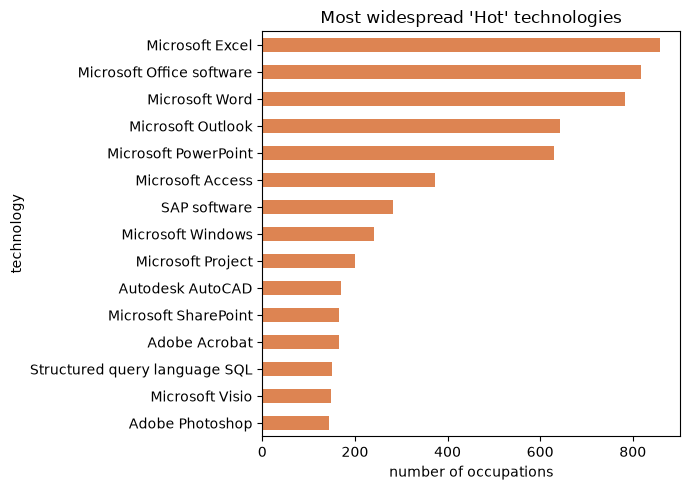

In [24]:
# EDA: technologies flagged Hot across the most occupations
hot = software_skills_df.rename(columns={"Workplace Example":"technology","Hot Technology":"hot"})
hot = hot[_yn(hot["hot"])]
top_hot = hot["technology"].str.strip().value_counts().head(15)

fig, ax = plt.subplots(figsize=(7, 5))
top_hot.iloc[::-1].plot.barh(ax=ax, color="#DD8452")
ax.set_title("Most widespread 'Hot' technologies")
ax.set_xlabel("number of occupations")
plt.tight_layout(); plt.show()

### 5.3 Competencies (InterMind signal, not an O\*NET concept)

`Essential Skills.txt` is O\*NET's **Skills** file: 35 broad worker characteristics (e.g. "Critical
Thinking", "Programming"), each rated per occupation on two scales via `Scale ID`:
- `IM`: Importance (how important the skill is to the role), O\*NET scale 1-5
- `LV`: Level (how much of the skill is needed), O\*NET scale 0-7

O\*NET Skills are **not** the same thing as an HR "competency" -- they are a fixed, occupation-agnostic
taxonomy, not job-specific behavioral competencies. Labeling them `competencies` in the knowledge-base
schema is an **InterMind transformation**: we treat O*NET's Importance rating as a proxy signal for which
skills matter most for a role, to drive competency-style interview questions later. This is an
application-level mapping, not an O*NET-native ranking.

Both `IM` and `LV` are preserved in the output record where available (Level is not discarded), since it
tells the application how much proficiency is expected, not just whether the skill matters. Selection is
by `IM` descending, top N per occupation; rows O\*NET flags `Recommend Suppress` or `Not Relevant` (`Y`)
are excluded.

In [25]:
def build_competencies(df, top_n=TOP_N_COMPETENCIES, min_importance=None):
    """InterMind transformation of O*NET's Skills file into a compact competency signal: top-N
    skills per occupation by Importance (IM), with Level (LV) preserved alongside when available.
    Excludes rows O*NET flags Recommend Suppress or Not Relevant ('Y'); a blank Not Relevant means
    O*NET did not flag it either way and the row is kept."""
    s = df.rename(columns={"O*NET-SOC Code":"onet_soc_code", "Element Name":"skill",
                           "Scale ID":"scale_id", "Data Value":"value",
                           "Recommend Suppress":"suppress", "Not Relevant":"not_relevant"}).copy()
    s = s[s["scale_id"].astype(str).str.upper().isin(["IM", "LV"])]
    s = s[~_yn(s["suppress"])]                              # drop low-quality rows
    s = s[~_yn(s["not_relevant"])]                           # drop O*NET-flagged not-relevant rows
    s["value"] = pd.to_numeric(s["value"], errors="coerce")
    s = s.dropna(subset=["value"])

    # Pivot IM/LV for the same (occupation, skill) into one row so Level rides alongside Importance.
    wide = (s.pivot_table(index=["onet_soc_code", "skill"], columns="scale_id",
                          values="value", aggfunc="first")
              .reset_index()
              .rename(columns={"IM": "importance", "LV": "level"}))
    for col in ("importance", "level"):
        if col not in wide.columns:
            wide[col] = np.nan
    wide = wide.dropna(subset=["importance"])   # importance drives ranking/selection
    if min_importance is not None:
        wide = wide[wide["importance"] >= min_importance]
    wide = wide.sort_values(["onet_soc_code", "importance"], ascending=[True, False])

    out = {}
    for code, g in wide.groupby("onet_soc_code"):
        records = []
        for r in g.head(top_n).itertuples():
            rec = {"skill": r.skill, "importance": round(float(r.importance), 2)}
            if pd.notna(r.level):
                rec["level"] = round(float(r.level), 2)
            records.append(rec)
        out[code] = records
    return out

comp_map = build_competencies(essential_skills_df)
print(f"Occupations with competencies: {len(comp_map)}")
example = next((c for c in comp_map if c.startswith("15-1252")), next(iter(comp_map)))
print(f"\nExample {example}:")
for row in comp_map[example][:8]:
    print("  ", row)

Occupations with competencies: 910

Example 15-1252.00:
   {'skill': 'Critical Thinking', 'importance': 3.88, 'level': 4.12}
   {'skill': 'Active Learning', 'importance': 3.5, 'level': 3.62}
   {'skill': 'Reading Comprehension', 'importance': 3.5, 'level': 4.25}
   {'skill': 'Active Listening', 'importance': 3.38, 'level': 3.88}
   {'skill': 'Writing', 'importance': 3.25, 'level': 3.62}
   {'skill': 'Speaking', 'importance': 3.12, 'level': 3.62}
   {'skill': 'Monitoring', 'importance': 3.0, 'level': 3.5}
   {'skill': 'Mathematics', 'importance': 2.75, 'level': 3.25}


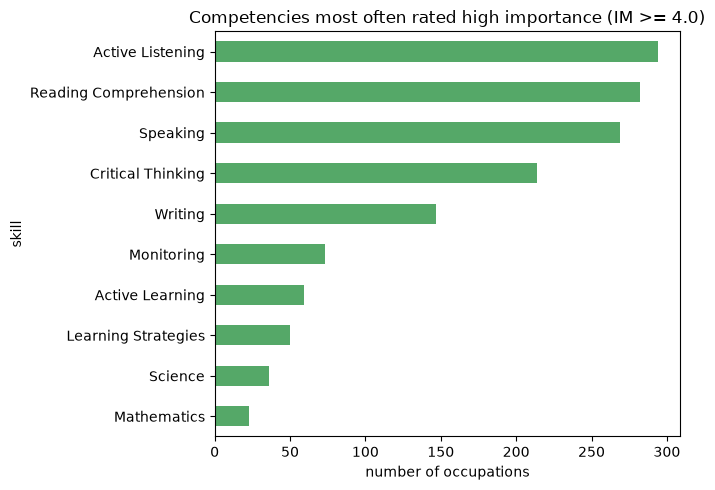

In [26]:
# EDA: competencies most often rated high importance (IM >= 4.0)
imp = essential_skills_df.rename(columns={"Element Name":"skill","Scale ID":"scale_id","Data Value":"value"})
imp = imp[imp["scale_id"].astype(str).str.upper().eq("IM")].copy()
imp["value"] = pd.to_numeric(imp["value"], errors="coerce")
high = imp[imp["value"] >= 4.0]["skill"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(7, 5))
high.iloc[::-1].plot.barh(ax=ax, color="#55A868")
ax.set_title("Competencies most often rated high importance (IM >= 4.0)")
ax.set_xlabel("number of occupations")
plt.tight_layout(); plt.show()

### 5.4 Tasks

`Task Statements` are role-specific activities tagged `Core` or `Supplemental` via `Task Type`. O*NET does
**not** provide an importance or ranking field for tasks (no `Data Value`/`IM` column here, unlike
Essential Skills) -- tasks below are not "most important tasks", they are tasks selected by this exact,
documented rule:

1. If an occupation has one or more `Core` tasks, only `Core` tasks are kept, in source-file order.
2. If an occupation has zero `Core` tasks (including a blank `Task Type`), all of its tasks are kept, in
   source-file order, as a fallback.
3. The result is capped at `TOP_N_CORE_TASKS` tasks per occupation.

Core tasks suit situational interview questions, which motivates preferring them, but "Core" is O\*NET's
own category label, not an importance ranking.

In [27]:
def build_tasks(df, top_n=TOP_N_CORE_TASKS):
    """Selects tasks per occupation: Core tasks only (source order) if any exist, else all tasks
    (source order) as a fallback, capped at top_n. No importance ranking exists in this source --
    see Section 5.4 for the exact rule."""
    k = df.rename(columns={"O*NET-SOC Code":"onet_soc_code","Task":"task","Task Type":"task_type"}).copy()
    k["task"] = k["task"].astype(str).str.strip()
    k["is_core"] = k["task_type"].astype(str).str.strip().str.lower().eq("core")
    k = k.sort_values(["onet_soc_code","is_core"], ascending=[True,False])
    out = {}
    for code, g in k.groupby("onet_soc_code"):
        core = g[g["is_core"]]
        chosen = core if len(core) else g          # fallback if no Core tasks
        out[code] = chosen["task"].head(top_n).tolist()
    return out

task_map = build_tasks(tasks_df)
print(f"Occupations with tasks: {len(task_map)}")
example = next((c for c in task_map if c.startswith("15-1252")), next(iter(task_map)))
print(f"\nExample {example}:")
for t in task_map[example][:5]:
    print("  -", t)

Occupations with tasks: 923

Example 15-1252.00:
  - Analyze user needs and software requirements to determine feasibility of design within time and cost constraints.
  - Develop or direct software system testing or validation procedures, programming, or documentation.
  - Confer with systems analysts, engineers, programmers and others to design systems and to obtain information on project limitations and capabilities, performance requirements and interfaces.
  - Modify existing software to correct errors, adapt it to new hardware, or upgrade interfaces and improve performance.
  - Prepare reports or correspondence concerning project specifications, activities, or status.


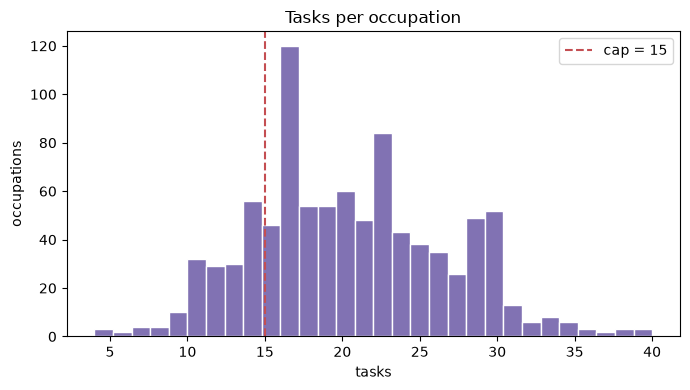

count    923.000000
mean      20.409534
std        6.288197
min        4.000000
25%       16.000000
50%       20.000000
75%       25.000000
max       40.000000
dtype: float64


In [28]:
# EDA: tasks per occupation, to confirm the cap is reasonable
counts = tasks_df.groupby("O*NET-SOC Code").size()
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(counts, bins=30, color="#8172B3", edgecolor="white")
ax.axvline(TOP_N_CORE_TASKS, color="#C44E52", linestyle="--", label=f"cap = {TOP_N_CORE_TASKS}")
ax.set_title("Tasks per occupation")
ax.set_xlabel("tasks"); ax.set_ylabel("occupations"); ax.legend()
plt.tight_layout(); plt.show()
print(counts.describe())

## 6. Assemble the knowledge base

The hub is joined with the three maps into one self-contained record per occupation. A `search_text` field (title,
description, top skill and tech names) is the string a matcher compares a JobSpec against.

In [29]:
def assemble_kb(occ, tech_map, comp_map, task_map):
    records = []
    for r in occ.itertuples():
        code = r.onet_soc_code
        comps = comp_map.get(code, [])   # InterMind competency signal (see Section 5.3)
        techs = tech_map.get(code, [])
        tasks = task_map.get(code, [])
        # Enriched text for matching and future embedding
        skill_str = " ".join(c["skill"] for c in comps)
        tech_str  = " ".join(t["technology"] for t in techs[:12])
        search_text = f"{r.title}. {r.description} Skills: {skill_str}. Technologies: {tech_str}".strip()
        records.append({
            "onet_soc_code": code,
            "title": r.title,
            "description": r.description,
            "competencies": comps,      # [{skill, importance, level?}], InterMind signal from O*NET Skills
            "technologies": techs,      # [{technology, category, hot, in_demand}]
            "core_tasks": tasks,        # [str]
            "search_text": search_text,
        })
    return records

kb = assemble_kb(occ_base, tech_map, comp_map, task_map)
print(f"Knowledge base: {len(kb)} occupations")

Knowledge base: 1016 occupations


In [30]:
# One full record, to see the shape a question generator receives
example = next((r for r in kb if r["onet_soc_code"].startswith("15-1252")), kb[0])
print(json.dumps(example, indent=2, ensure_ascii=False)[:2000])

{
  "onet_soc_code": "15-1252.00",
  "title": "Software Developers",
  "description": "Research, design, and develop computer and network software or specialized utility programs. Analyze user needs and develop software solutions, applying principles and techniques of computer science, engineering, and mathematical analysis. Update software or enhance existing software capabilities. May work with computer hardware engineers to integrate hardware and software systems, and develop specifications and performance requirements. May maintain databases within an application area, working individually or coordinating database development as part of a team.",
  "competencies": [
    {
      "skill": "Critical Thinking",
      "importance": 3.88,
      "level": 4.12
    },
    {
      "skill": "Active Learning",
      "importance": 3.5,
      "level": 3.62
    },
    {
      "skill": "Reading Comprehension",
      "importance": 3.5,
      "level": 4.25
    },
    {
      "skill": "Active Listeni

In [31]:
def _is_json_serializable(obj) -> bool:
    try:
        json.dumps(obj)
        return True
    except (TypeError, ValueError):
        return False

### 6.1 Validate

In [32]:
# Structural integrity checks before trusting the artifact
n = len(kb)
codes_list = [r["onet_soc_code"] for r in kb]
dup_kb_codes = [c for c in set(codes_list) if codes_list.count(c) > 1]
missing_title = sum(1 for r in kb if not r["title"])
missing_desc  = sum(1 for r in kb if not r["description"])
no_comp = sum(1 for r in kb if not r["competencies"])
no_tech = sum(1 for r in kb if not r["technologies"])
no_task = sum(1 for r in kb if not r["core_tasks"])
fully_empty = sum(1 for r in kb if not (r["competencies"] or r["technologies"] or r["core_tasks"]))
over_cap = sum(1 for r in kb if len(r["competencies"]) > TOP_N_COMPETENCIES
               or len(r["technologies"]) > TOP_N_TECHNOLOGIES
               or len(r["core_tasks"]) > TOP_N_CORE_TASKS)

print(f"records                 : {n}")
print(f"duplicate onet_soc_code : {len(dup_kb_codes)}   (must be 0)")
print(f"missing title/desc      : {missing_title} / {missing_desc}   (must be 0)")
print(f"no competencies         : {no_comp}")
print(f"no technologies         : {no_tech}")
print(f"no core tasks           : {no_task}")
print(f"completely empty roles  : {fully_empty}")
print(f"records exceeding caps  : {over_cap}   (must be 0)")

assert missing_title == 0 and missing_desc == 0, "every occupation needs a title and description"
assert len(dup_kb_codes) == 0, f"duplicate onet_soc_code in kb: {dup_kb_codes[:5]}"
assert over_cap == 0, "a record exceeds its configured cap"

# JSON serializability -- the application layer consumes this as JSONL
bad_json = [r["onet_soc_code"] for r in kb if not _is_json_serializable(r)]
assert not bad_json, f"non-JSON-serializable records: {bad_json[:5]}"
print("All records are JSON-serializable.")

avg_c = sum(len(r["competencies"]) for r in kb)/n
avg_t = sum(len(r["technologies"]) for r in kb)/n
avg_k = sum(len(r["core_tasks"]) for r in kb)/n
print(f"\navg per role: competencies {avg_c:.1f} | technologies {avg_t:.1f} | tasks {avg_k:.1f}")
print("Structural validation passed")

records                 : 1016
duplicate onet_soc_code : 0   (must be 0)
missing title/desc      : 0 / 0   (must be 0)
no competencies         : 106
no technologies         : 93
no core tasks           : 93
completely empty roles  : 93
records exceeding caps  : 0   (must be 0)
All records are JSON-serializable.

avg per role: competencies 9.0 | technologies 15.9 | tasks 11.6
Structural validation passed


## 7. Export artifacts

Three dependency-light files, so the backend needs no new libraries:
- `onet_kb.jsonl`: knowledge base, one occupation per line. Primary artifact.
- `occupation_index.csv`: slim lookup (code, title, description, `search_text`, counts) for matching and embedding.
- `onet_kb_meta.json`: provenance, build config, counts.

In [33]:
# 1) JSONL knowledge base
kb_path = OUT_DIR / "onet_kb.jsonl"
with open(kb_path, "w", encoding="utf-8") as f:
    for r in kb:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

# 2) CSV index (dependency-free lookup / embedding input)
index_path = OUT_DIR / "occupation_index.csv"
pd.DataFrame([{
    "onet_soc_code": r["onet_soc_code"], "title": r["title"], "description": r["description"],
    "search_text": r["search_text"],
    "n_competencies": len(r["competencies"]),
    "n_technologies": len(r["technologies"]),
    "n_core_tasks": len(r["core_tasks"]),
} for r in kb]).to_csv(index_path, index=False)

# 3) Meta / provenance
meta = {
    "onet_version": ONET_VERSION,
    "source": "O*NET db_31_0_text (Occupation Data, Software Skills, Essential Skills, Task Statements)",
    "built_at": datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
    "n_occupations": len(kb),
    "config": {"top_n_technologies": TOP_N_TECHNOLOGIES,
               "top_n_competencies": TOP_N_COMPETENCIES,
               "top_n_core_tasks": TOP_N_CORE_TASKS},
    "record_schema": {
        "onet_soc_code": "str, O*NET-SOC code (join key)",
        "title": "str", "description": "str",
        "competencies": (
            "[{skill, importance, level?}] -- InterMind signal derived from O*NET's Skills file "
            "('Essential Skills.txt'), NOT an O*NET-native 'competency'. importance = IM scale "
            "(1-5), level = LV scale (0-7, present only when O*NET reported it). Ranked/capped by "
            "importance descending."
        ),
        "technologies": (
            "[{technology, category, hot, in_demand}] from O*NET Software Skills. hot/in_demand "
            "are O*NET-provided flags; the order within the list is an InterMind heuristic "
            "(hot > in_demand > alphabetical), not an O*NET ranking."
        ),
        "core_tasks": (
            "[str] from O*NET Task Statements. Core tasks only if any exist for the occupation, "
            "else all tasks as a fallback, source order, capped -- no O*NET importance ranking "
            "exists for tasks."
        ),
        "search_text": "str, title+description+skills+tech for matching/embedding",
    },
}
meta_path = OUT_DIR / "onet_kb_meta.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

for p in (kb_path, index_path, meta_path):
    print(f"{p.name:<24} {p.stat().st_size/1024:8.1f} KB")

onet_kb.jsonl              4607.1 KB

occupation_index.csv        860.1 KB
onet_kb_meta.json             1.2 KB


In [34]:
# README next to the data so the artifact documents itself in the repo
readme = f'''# O*NET Interview Knowledge Base

Built from O*NET {ONET_VERSION} for InterMind (Milestone 2). One record per occupation. Generated by
`notebooks/ONET_knowledge_base_pipeline.ipynb` -- do not hand-edit these files, rerun the notebook instead.

## Files
- onet_kb.jsonl: full knowledge base, one occupation per line
- occupation_index.csv: slim lookup (code, title, description, search_text, counts)
- onet_kb_meta.json: provenance, build config, record schema

## Record schema (onet_kb.jsonl)
```json
{{
  "onet_soc_code": "15-1252.00",
  "title": "Software Developers",
  "description": "...",
  "competencies": [{{"skill": "Programming", "importance": 4.75, "level": 6.0}}],
  "technologies": [{{"technology": "Python", "category": "...", "hot": true, "in_demand": true}}],
  "core_tasks": ["Write, analyze, and debug application code."],
  "search_text": "Software Developers. ... Skills: ... Technologies: ..."
}}
```

## Important semantics (read before consuming this data)
- `competencies` is an **InterMind transformation** of O*NET's Skills file ("Essential Skills.txt"), not
  an O*NET-native "competency". `importance` = O*NET's Importance (IM) rating, 1-5; `level` = O*NET's
  Level (LV) rating, 0-7, included only when O*NET reported it. Selection is importance-ranked, top N.
- `technologies` ordering (`hot` > `in_demand` > alphabetical) is an **InterMind-defined heuristic** for
  capping the list, not an O*NET-provided ranking. `hot`/`in_demand` themselves are O*NET flags.
- `core_tasks` are selected by O*NET's own `Core`/`Supplemental` label (Core preferred, all tasks as a
  fallback if an occupation has none), capped per occupation -- O*NET provides no task importance
  ranking, so these are not "most important tasks".

## Pipeline
JobSpec > match on search_text > occupation record > competencies + technologies + core_tasks > questions
- competencies: competency / behavioural questions
- technologies: tech-specific questions (prefer hot / in_demand)
- core_tasks: situational / scenario questions

The JobSpec-to-occupation matcher demonstrated in the notebook (TF-IDF over `search_text`) is a
proof-of-concept retrieval demonstration, not a validated occupation classifier -- no labeled evaluation
set exists yet to measure its accuracy.

## Provenance
Derived from O*NET {ONET_VERSION} (Occupation Data, Software Skills, Essential Skills, Task Statements),
joined on O*NET-SOC Code. O*NET data is provided by the U.S. Department of Labor under CC BY 4.0.
'''
(OUT_DIR / "README.md").write_text(readme, encoding="utf-8")
print("README.md written to", OUT_DIR / "README.md")

README.md written to C:\Users\Aliyah\Autonomous-AI-Interviewer\data\processed\onet\README.md


## 8. Bridge: JobSpec to occupation (proof-of-concept, not a classifier)

A minimal demo of the seam to Milestone 3, not the final matcher. TF-IDF over `search_text` shows the
knowledge base is queryable from a JobSpec-like string today. **This is a retrieval/matching
demonstration on one hand-picked query, not a validated occupation classifier** -- no labeled
ground-truth set exists to measure precision/recall, so no accuracy claim is made or implied. It stays in
the notebook, not the backend.

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

class OccupationMatcher:
    """JobSpec to occupation matcher over search_text. Replace TF-IDF with embeddings later."""
    def __init__(self, records):
        self.codes  = [r["onet_soc_code"] for r in records]
        self.titles = [r["title"] for r in records]
        self.vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)
        self.M = self.vec.fit_transform([r["search_text"] for r in records])
    def match(self, query, k=5):
        sims = cosine_similarity(self.vec.transform([query]), self.M)[0]
        idx = np.argsort(sims)[::-1][:k]
        return [(self.codes[i], self.titles[i], round(float(sims[i]), 3)) for i in idx]

matcher = OccupationMatcher(kb)

# Text a JobSpec would produce from a backend-engineer JD
jobspec_query = ("Backend Software Engineer. Build and maintain REST APIs and microservices. "
                 "Skills: Python, programming, debugging, system design, databases.")
print("JobSpec query:\n ", jobspec_query, "\n\nTop matches:")
for code, title, score in matcher.match(jobspec_query, k=5):
    print(f"  {score:>5}  {code}  {title}")

JobSpec query:
  Backend Software Engineer. Build and maintain REST APIs and microservices. Skills: Python, programming, debugging, system design, databases. 

Top matches:
  0.145  15-1243.00  Database Architects
  0.127  15-2099.01  Bioinformatics Technicians
  0.116  15-1299.05  Information Security Engineers
    0.1  17-3024.01  Robotics Technicians
  0.093  17-3029.08  Photonics Technicians


A software-engineering JobSpec surfacing Software Developers and related roles near the top demonstrates
the chain from JD to occupation to competencies, technologies and tasks works end-to-end on this one
example -- it is not a measurement of matcher accuracy.

Upgrade path (Milestone 3+): replace `TfidfVectorizer` with embeddings, precomputing one vector per `search_text` and
storing it beside the index, using the existing OpenAI client. TF-IDF remains the offline fallback.

## 9. Repo integration

When run locally inside the repo checkout (the normal case), Section 1 resolves `PROCESSED_DIR` to
`data/processed/onet/` and the artifacts above are already in place:

```
Autonomous-AI-Interviewer/
  data/
    processed/
      onet/
        onet_kb.jsonl          primary knowledge base (load this)
        occupation_index.csv   slim lookup for matching / embeddings
        onet_kb_meta.json      provenance and schema
        README.md              documents the artifact in-repo
```

No manual copy step is needed in that case. If this notebook is instead run in a bare Colab runtime with
no repo checked out (`IN_COLAB` and no `pyproject.toml` found), artifacts land under `/content/data/processed/onet/`
and must be downloaded and placed at that same `data/processed/onet/` path manually.

The raw O*NET release under `data/raw/onet/` and this notebook are not meant to be copied anywhere; only
the small processed artifact in `data/processed/onet/` is a build output the rest of the project depends on.

No backend changes this milestone. In Milestone 3, a reader for this KB belongs in an isolated module
(`app/knowledge/onet_kb.py`) exposing `get_occupation(code)` and `match_jobspec(jobspec)`. It consumes
`data/processed/onet/` and does not touch the existing FastAPI, `JobSpec`, or repository code.

## 10. Final validation summary

One consolidated report, re-using the checks already run above, so it is obvious at a glance whether
Milestone 2 passed.

In [36]:
print("=" * 70)
print("MILESTONE 2 FINAL VALIDATION SUMMARY")
print("=" * 70)

print("\n--- Source row counts ---")
print(f"Occupation Data   : {len(occupation_df):>6} rows, {occupation_df['O*NET-SOC Code'].nunique()} unique codes")
print(f"Software Skills   : {len(software_skills_df):>6} rows")
print(f"Essential Skills  : {len(essential_skills_df):>6} rows")
print(f"Task Statements    : {len(tasks_df):>6} rows")

print("\n--- Occupation / knowledge-base counts ---")
print(f"Occupations (hub)     : {len(occ_codes)}")
print(f"Knowledge-base records: {len(kb)}")

total_orphans = sum(len(v) for v in referential_orphans.values())
checks = {
    "occupation count matches KB record count": len(occ_codes) == len(kb),
    "no duplicate O*NET-SOC Code in hub (source)": dup_occ == 0,
    "no duplicate onet_soc_code in KB (output)": len(dup_kb_codes) == 0,
    "no missing/blank join codes in any source table": all(
        count_missing_codes(df) == 0
        for df in (occupation_df, software_skills_df, essential_skills_df, tasks_df)
    ),
    "no orphan detail rows (all codes resolve to the hub)": total_orphans == 0,
    "no missing title/description in the KB": missing_title == 0 and missing_desc == 0,
    "no KB record exceeds its configured cap": over_cap == 0,
    "all KB records are JSON-serializable": not bad_json,
}

print("\n--- Checks ---")
for label, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}")

print("\n--- Missing-value handling summary ---")
print("Essential Skills 'Not Relevant': blank = O*NET did not flag relevance either way -> row KEPT;")
print("  'Y' = O*NET flagged it not relevant -> row EXCLUDED from the competency signal.")
print("Tasks 'Task Type': blank treated as non-Core (only used via the zero-Core-tasks fallback).")
print("Tasks 'Incumbents Responding': survey metadata, not loaded into the knowledge base at all.")

print("\n--- Output files ---")
for p in (kb_path, index_path, meta_path, OUT_DIR / "README.md"):
    exists = p.exists()
    size_kb = p.stat().st_size / 1024 if exists else 0
    print(f"  {str(p):<70} exists={exists}  {size_kb:8.1f} KB")

print("\n--- Sample final knowledge-base record ---")
sample = next((r for r in kb if r["onet_soc_code"].startswith("15-1252")), kb[0])
print(json.dumps(sample, indent=2, ensure_ascii=False)[:1200], "\n  ...")

overall_pass = all(checks.values())
print("\n" + "=" * 70)
print(f"MILESTONE 2: {'PASS' if overall_pass else 'FAIL -- see checks above'}")
print("=" * 70)
assert overall_pass, "Milestone 2 final validation failed -- see the check list above"

MILESTONE 2 FINAL VALIDATION SUMMARY

--- Source row counts ---
Occupation Data   :   1016 rows, 1016 unique codes
Software Skills   :  31821 rows
Essential Skills  :  18200 rows
Task Statements    :  18838 rows

--- Occupation / knowledge-base counts ---
Occupations (hub)     : 1016
Knowledge-base records: 1016

--- Checks ---
  [PASS] occupation count matches KB record count
  [PASS] no duplicate O*NET-SOC Code in hub (source)
  [PASS] no duplicate onet_soc_code in KB (output)
  [PASS] no missing/blank join codes in any source table
  [PASS] no orphan detail rows (all codes resolve to the hub)
  [PASS] no missing title/description in the KB
  [PASS] no KB record exceeds its configured cap
  [PASS] all KB records are JSON-serializable

--- Missing-value handling summary ---
Essential Skills 'Not Relevant': blank = O*NET did not flag relevance either way -> row KEPT;
  'Y' = O*NET flagged it not relevant -> row EXCLUDED from the competency signal.
Tasks 'Task Type': blank treated as no

### Milestone 2 summary
- Established the O\*NET relational model (one hub, three detail tables on `O*NET-SOC Code`) and validated
  it: source column/type checks, duplicate-key checks, referential integrity, and numeric-range checks
  against O*NET's documented scales
- Reduced each table to an interview signal (technologies, competencies, core tasks), with the O*NET vs.
  InterMind distinction made explicit for each (Sections 5.2-5.4)
- Assembled and structurally validated a one-record-per-occupation knowledge base (deterministic,
  JSON-serializable, capped per the configured limits)
- Exported dependency-light artifacts to `data/processed/onet/`
- Demonstrated (not validated) the JobSpec-to-occupation bridge as a retrieval proof-of-concept

### Limitations
- Coverage gaps are real, not a bug: ~90% of occupations carry technology/skill/task signal; the rest keep
  empty lists rather than being dropped (Section 4)
- The TF-IDF JobSpec matcher (Section 8) has no labeled evaluation set -- its match quality beyond the one
  worked example is unknown
- `competencies` carries O*NET's Importance/Level ratings as a proxy signal, not a validated measure of
  interview-relevant competency

### Next: Milestone 3, Interview Planning
Occupation to competency-coverage plan to role-specific questions to LangGraph workflow. Not started here.